# Phase 0 / Project 1 起步：ResNet-50 多后端推理

> **一句话心智模型：** 同一组 weights 和同一个 `[1, 3, 224, 224]` tensor，分别交给四套“图表示 + compiler/runtime + kernel/device”流水线；先证明 logits 足够一致，再比较冷启动和稳态 latency。

这一步在 `Learning-Guide.md` 中严格属于正式 Transformer Project 1 之前的 **Core ML Foundation C0–C4**。我们先用 ResNet-50 建立可复现闭环，之后再把同一套观察方法迁移到 Transformer、公司 SoC 和 NPU compiler。

完成后你应该能回答：

1. PyTorch eager、`torch.compile`、ONNX Runtime、Core ML 各把模型保存成什么数据结构？
2. export / compile / load / first run / warm run 为什么必须拆开计时？
3. 如何用 FX graph、ONNX Protobuf、ORT profile、MIL 和 `MLComputePlan` 找到底层调用差异？
4. 为什么“某后端更快”不自动等于“compiler 更好”？

## Goal：先画出四条执行链

把你熟悉的 OS / 组成原理映射过来：graph/IR 类似“中间指令”，runtime 类似“loader + scheduler”，backend/kernel 类似“具体 ISA/库实现”。

| 路径 | compiler/runtime 链 | 本实验可检查的证据 |
|---|---|---|
| PyTorch eager | Python `nn.Module` → ATen dispatcher → CPU/MPS kernel | module tree、`torch.profiler` |
| `torch.compile` | TorchDynamo guards/FX → AOTAutograd → TorchInductor → C++ code/cache | FX graph、graph break、Inductor cache |
| ONNX Runtime | ONNX `ModelProto` → graph optimization → Execution Provider → kernel | raw/optimized ONNX、ORT profile JSON |
| Core ML | TorchScript graph → MIL passes → ML Program → `.mlmodelc` → Core ML runtime → CPU/GPU/ANE | TorchScript IR、MIL、compiled `model.mil`、Compute Plan、Instruments |

我们保留两种解读口径：

- **受控 CPU / FP32 lane**：eager CPU、Inductor CPU、ORT CPU、Core ML FP32 `CPU_ONLY`。它较适合比较 runtime/compiler，但线程池和 kernel library 仍不完全相同。
- **平台推荐 lane**：PyTorch MPS FP32 与 Core ML FP16 `ALL`。它回答“在这台 Mac 上怎样部署更快”，但混合了 device 与 precision 差异，不能当作纯 compiler 排名。

## Setup：启动方式与实验合同

从仓库根目录执行：

```bash
uv sync
uv run jupyter lab notebooks/phase0_coreml_foundation/01_resnet50_backend_comparison.ipynb
```

本 notebook 默认 `warmup=5`、`runs=30`，目的是十几秒内完成一次教学实验。正式写 benchmark report 时改为至少 3 个独立进程、每个进程 `runs>=100`；MacBook Air 无风扇，要把热降频视作实验变量。

In [44]:
from pathlib import Path
from collections import Counter
from datetime import datetime
import copy
import gc
import hashlib
import json
import os
import platform
import shutil
import subprocess
import time

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
RUN_ID = datetime.now().strftime("%Y%m%d-%H%M%S")
RUN_DIR = ROOT / "results" / "phase0_resnet50" / RUN_ID
PROFILE_DIR = RUN_DIR / "profiler"
COMPILE_CACHE = RUN_DIR / "torchinductor_cache"
for path in [RUN_DIR, PROFILE_DIR, COMPILE_CACHE]:
    path.mkdir(parents=True, exist_ok=True)

# 为本次运行使用全新的 cache，避免把之前编译过的结果误记为 cold compile。
os.environ["TORCHINDUCTOR_CACHE_DIR"] = str(COMPILE_CACHE)

import coremltools as ct
import matplotlib.pyplot as plt
import nbformat
import numpy as np
import onnx
import onnxruntime as ort
import pandas as pd
import torch
import torchvision
from coremltools.models.compute_plan import MLComputePlan
from IPython.display import Markdown, display
from PIL import Image
from torchvision.models import ResNet50_Weights, resnet50

CPU_THREADS = 4            # M1 有 4 个 performance cores；PyTorch 与 ORT 都显式使用该值。
INPUT_SHAPE = (1, 3, 224, 224)
WARMUP = 5
RUNS = 30
torch.set_num_threads(CPU_THREADS)
pd.set_option("display.max_colwidth", 90)

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def sha256_path(path: Path) -> str:
    if path.is_file():
        return sha256_file(path)
    digest = hashlib.sha256()
    for file_path in sorted(item for item in path.rglob("*") if item.is_file()):
        digest.update(str(file_path.relative_to(path)).encode())
        with file_path.open("rb") as file:
            for chunk in iter(lambda: file.read(1024 * 1024), b""):
                digest.update(chunk)
    return digest.hexdigest()

def size_mb(path: Path) -> float:
    files = [path] if path.is_file() else [item for item in path.rglob("*") if item.is_file()]
    return sum(item.stat().st_size for item in files) / 1e6

def command_output(command: list[str]) -> str:
    return subprocess.check_output(command, text=True).strip()

In [45]:
environment = {
    "run_id": RUN_ID,
    "python": platform.python_version(),
    "macOS": platform.mac_ver()[0],
    "machine": platform.machine(),
    "chip": command_output(["sysctl", "-n", "machdep.cpu.brand_string"]),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "onnx": onnx.__version__,
    "onnxruntime": ort.__version__,
    "coremltools": ct.__version__,
    "coremlcompiler": command_output(["xcrun", "coremlcompiler", "version"]),
    "MPS available": torch.backends.mps.is_available(),
    "ORT providers": ort.get_available_providers(),
    "CPU threads": CPU_THREADS,
}
display(pd.Series(environment, name="value").to_frame())

,value
run_id,20260829-123224
python,3.12.11
macOS,26.6.2
machine,arm64
chip,Apple M1
torch,2.7.0
torchvision,0.22.0
onnx,1.22.0
onnxruntime,1.29.0
coremltools,9.0


### 为什么固定 PyTorch 2.7？

`uv` 如果不约束会解析到更新的 PyTorch，但 Core ML Tools 9.0 的已验证支持写的是 PyTorch 2.7。模型部署首先需要一个版本合同，而不是“import 成功就算兼容”。版本依据见 [Core ML Tools releases](https://github.com/apple/coremltools/releases)。

另一个值得现场确认的点是 `ort.get_available_providers()`：主 ONNX 实验仍显式指定 `CPUExecutionProvider`。即使系统提供 `CoreMLExecutionProvider`，也不能让 runtime 自动选择，否则 ONNX lane 可能偷偷混入 Core ML 分区。

## Steps 1：下载并固定唯一的 model / input

**它演示什么：** 四个 backend 必须从同一份 weights 和同一个已经完成 preprocessing 的 tensor 出发。图片 decode、resize、crop、normalize 都不计入 inference latency。

`ResNet50_Weights.IMAGENET1K_V2` 的 preprocessing 合同是：resize 232、center crop 224、ImageNet mean/std normalization。weights API 见 [torchvision ResNet-50 文档](https://docs.pytorch.org/vision/0.22/models/generated/torchvision.models.resnet50.html)。

In [46]:
WEIGHTS = ResNet50_Weights.IMAGENET1K_V2
WEIGHT_PATH = ROOT / "models" / "resnet50" / "resnet50-imagenet1k-v2.pth"
IMAGE_PATH = ROOT / "datasets" / "images" / "dog.jpg"
WEIGHT_PATH.parent.mkdir(parents=True, exist_ok=True)
IMAGE_PATH.parent.mkdir(parents=True, exist_ok=True)

if not WEIGHT_PATH.exists():
    torch.hub.download_url_to_file(WEIGHTS.url, str(WEIGHT_PATH), progress=True)
if not IMAGE_PATH.exists():
    torch.hub.download_url_to_file(
        "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg",
        str(IMAGE_PATH),
        progress=True,
    )

weight_sha256 = sha256_file(WEIGHT_PATH)
expected_hash_prefix = WEIGHTS.url.rsplit("-", 1)[1].split(".")[0]
assert weight_sha256.startswith(expected_hash_prefix)

load_start = time.perf_counter_ns()
eager_model = resnet50(weights=None).eval()
state_dict = torch.load(WEIGHT_PATH, map_location="cpu", weights_only=True)
eager_model.load_state_dict(state_dict)
pytorch_model_load_ms = (time.perf_counter_ns() - load_start) / 1e6

image = Image.open(IMAGE_PATH).convert("RGB")
input_tensor = WEIGHTS.transforms()(image).unsqueeze(0).contiguous()
input_numpy = input_tensor.numpy()
categories = WEIGHTS.meta["categories"]

model_contract = {
    "weights": "ResNet50_Weights.IMAGENET1K_V2",
    "weights_url": WEIGHTS.url,
    "weights_sha256": weight_sha256,
    "image_sha256": sha256_file(IMAGE_PATH),
    "input_tensor_sha256": hashlib.sha256(input_numpy.tobytes()).hexdigest(),
    "parameters": sum(parameter.numel() for parameter in eager_model.parameters()),
    "input_shape": list(input_tensor.shape),
    "input_dtype": str(input_tensor.dtype),
    "input_stride": list(input_tensor.stride()),
    "preprocess": str(WEIGHTS.transforms()),
}
assert tuple(input_tensor.shape) == INPUT_SHAPE
assert input_tensor.dtype == torch.float32 and input_tensor.is_contiguous()
display(pd.Series(model_contract, name="value").to_frame())

,value
weights,ResNet50_Weights.IMAGENET1K_V2
weights_url,https://download.pytorch.org/models/resnet50-11ad3fa6.pth
weights_sha256,11ad3fa62ca79e40addfd354a8ec4b7c75143b3038b8d2a807fbc68deab379ca
image_sha256,f3f87bb8ab3c26c7ecfd3ac60421d7f32b0503d1d6c5baf8bac42ed93d86351a
input_tensor_sha256,92994d4d2219bc519966adfcbbbf768417e94cb4d37fe97ccef739f766abb538
parameters,25557032
input_shape,"[1, 3, 224, 224]"
input_dtype,torch.float32
input_stride,"[150528, 50176, 224, 1]"
preprocess,"ImageClassification(\n crop_size=[224]\n resize_size=[232]\n mean=[0.485, 0.4..."


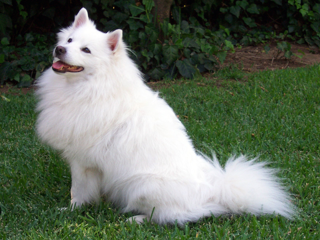

,class_id,class_name,probability
0,258,Samoyed,0.4366
1,270,white wolf,0.0211
2,259,Pomeranian,0.0132
3,257,Great Pyrenees,0.0080
4,248,Eskimo dog,0.0059


PyTorch eager CPU first inference: 77.19 ms


In [47]:
eager_first_start = time.perf_counter_ns()
with torch.inference_mode():
    eager_output = eager_model(input_tensor).numpy()
eager_first_ms = (time.perf_counter_ns() - eager_first_start) / 1e6
np.save(RUN_DIR / "reference_logits.npy", eager_output)

probabilities = torch.from_numpy(eager_output).softmax(dim=1)[0]
top_probabilities, top_indices = probabilities.topk(5)
top5 = pd.DataFrame(
    {
        "class_id": top_indices.numpy(),
        "class_name": [categories[index] for index in top_indices],
        "probability": top_probabilities.numpy(),
    }
)
display(image.resize((320, 240)))
display(top5.style.format({"probability": "{:.4f}"}))
print(f"PyTorch eager CPU first inference: {eager_first_ms:.2f} ms")

**怎么验证：** Top-1 应是 `Samoyed`。但这只证明单张图片的语义结果合理，不等于 ImageNet accuracy 已验证；正式 accuracy 要跑带标签数据集。后面的 correctness gate 还会比较全部 1000 个 logits。

## Steps 2：从 Python object tree 走到 compiler graph

`nn.Module` 更像一棵带 Python 行为的对象树；compiler 需要的是显式 node/edge、shape、dtype 和常量。`torch.export` 会把模型捕获成 `ExportedProgram`，其核心仍是 FX `GraphModule`。

ResNet-50 没有复杂 control flow，因此固定 shape 的 graph capture 很直接。`run_decompositions({})` 把 PyTorch 2.7 导出的 `TRAINING` dialect 规整为更标准的 `ATEN` dialect；本实验的 Core ML 主路径仍使用支持更久的 TorchScript trace。

In [48]:
print("Python module tree 的一个 residual bottleneck：")
display(eager_model.layer1[0])

export_start = time.perf_counter_ns()
exported_program = torch.export.export(eager_model, (input_tensor,), strict=True).run_decompositions({})
torch_export_ms = (time.perf_counter_ns() - export_start) / 1e6
TORCH_EXPORT_PATH = ROOT / "artifacts" / "resnet50" / "resnet50_exported.pt2"
TORCH_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.export.save(exported_program, TORCH_EXPORT_PATH)

fx_nodes = list(exported_program.graph.nodes)
fx_preview = pd.DataFrame(
    [
        {"op": node.op, "name": node.name, "target": str(node.target)[:90]}
        for node in fx_nodes[:20]
    ]
)
input_kinds = Counter(spec.kind.name for spec in exported_program.graph_signature.input_specs)
(PROFILE_DIR / "torch_export_graph.txt").write_text(str(exported_program.graph), encoding="utf-8")

print(f"dialect={exported_program.dialect}, FX nodes={len(fx_nodes)}, export={torch_export_ms:.2f} ms")
print("graph signature 中的输入种类：", dict(input_kinds))
display(fx_preview)

Python module tree 的一个 residual bottleneck：


Bottleneck(
  (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (downsample): Sequential(
    (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

Unsupported: Attempt to trace generator
  Explanation: Generators cannot be compiled directly with `torch.compile`.
  Hint: Call a generator from inside of a non-generator Python function and compile that function instead.
  Hint: This graph break is fundamental - it is unlikely that Dynamo will ever be able to trace through your code. Consider finding a workaround.

  Developer debug context: 


注意 graph signature 里大多数 `PARAMETER` / `BUFFER` 是被“抬升”为图输入的 weights 与 BatchNorm state，真正用户提供的图片只有一个 `USER_INPUT`。这与 C++ 里把隐式成员状态改写成显式函数参数是同一类 compiler 变换。

## Steps 3：PyTorch eager 的 CPU 与 MPS 路径

MPS 把 ATen op 交给 Metal Performance Shaders。GPU 提交是异步的，所以计时前后必须 `torch.mps.synchronize()`；同时把输出复制回 host，才能与 ORT/Core ML 的 Python API 口径接近。

In [ ]:
assert torch.backends.mps.is_available()
mps_load_start = time.perf_counter_ns()
mps_model = copy.deepcopy(eager_model).to("mps").eval()
input_mps = input_tensor.to("mps")
torch.mps.synchronize()
mps_model_load_ms = (time.perf_counter_ns() - mps_load_start) / 1e6

torch.mps.synchronize()
mps_first_start = time.perf_counter_ns()
with torch.inference_mode():
    mps_output = mps_model(input_mps).cpu().numpy()
torch.mps.synchronize()
mps_first_ms = (time.perf_counter_ns() - mps_first_start) / 1e6
print(f"MPS model/input transfer={mps_model_load_ms:.2f} ms, first inference={mps_first_ms:.2f} ms")

MPS model/input transfer=420.56 ms, first inference=262.66 ms


## Steps 4：`torch.compile`（CPU TorchInductor）

**关键点：** `torch.compile(...)` 只创建 lazy wrapper；第一次 forward 才执行 graph capture、guard、lowering、codegen、native compilation 和第一帧。这里把 wrapper 时间与 first-call 时间分开。

`fullgraph=True` 的含义类似“这个函数必须完整编成一个 translation unit”；遇到 graph break 就直接报错，避免静默退回 eager。官方入口见 [`torch.compile` 文档](https://docs.pytorch.org/docs/2.7/generated/torch.compile.html)。

In [ ]:
explain_start = time.perf_counter_ns()
with torch.inference_mode():
    dynamo_explain = torch._dynamo.explain(eager_model)(input_tensor)
dynamo_explain_ms = (time.perf_counter_ns() - explain_start) / 1e6

wrapper_start = time.perf_counter_ns()
compiled_model = torch.compile(
    eager_model,
    backend="inductor",
    fullgraph=True,
    dynamic=False,
)
compile_wrapper_ms = (time.perf_counter_ns() - wrapper_start) / 1e6

compiled_first_start = time.perf_counter_ns()
with torch.inference_mode():
    compiled_output = compiled_model(input_tensor).numpy()
compiled_first_ms = (time.perf_counter_ns() - compiled_first_start) / 1e6

print(
    f"Dynamo graphs={dynamo_explain.graph_count}, graph breaks={dynamo_explain.graph_break_count}, "
    f"wrapper={compile_wrapper_ms:.2f} ms, first call (compile + run)={compiled_first_ms:.2f} ms"
)
assert dynamo_explain.graph_count == 1 and dynamo_explain.graph_break_count == 0

Dynamo graphs=1, graph breaks=0, wrapper=3.25 ms, first call (compile + run)=5094.14 ms


In [ ]:
cache_files = [path for path in COMPILE_CACHE.rglob("*") if path.is_file()]
cache_summary = pd.DataFrame(
    [
        {"suffix": suffix or "<no suffix>", "file_count": count}
        for suffix, count in Counter(path.suffix for path in cache_files).most_common()
    ]
)
print(f"Inductor cache: {len(cache_files)} files, {size_mb(COMPILE_CACHE):.2f} MB")
display(cache_summary)

source_candidates = [path for path in cache_files if path.suffix in {".cpp", ".py"}]
generated_source = source_candidates[0]
source_preview = generated_source.read_text(encoding="utf-8", errors="replace").splitlines()[:24]
print(f"生成代码示例：{generated_source.relative_to(ROOT)}")
print("\n".join(source_preview))

Inductor cache: 25 files, 0.97 MB


,suffix,file_count
0,.cpp,22
1,<no suffix>,2
2,.py,1


生成代码示例：results/phase0_resnet50/20260829-122145/torchinductor_cache/zy/czy7ekwrzbitbtxun2na2dkvnyy4m3og56qg2hy7x2wpkdjpj7q6.cpp

#include "/Users/yhwang/infer-proj/results/phase0_resnet50/20260828-215306/torchinductor_cache/pi/cpicxudqmdsjh5cm4klbtbrvy2cxwr7whxl3md2zzdjdf3orvfdf.h"
extern "C"  void kernel(float* in_out_ptr0,
                       const float* in_ptr0,
                       const float* in_ptr1,
                       const float* in_ptr2,
                       const float* in_ptr3,
                       const float* in_ptr4,
                       float* out_ptr0)
{
    #pragma omp parallel num_threads(4)
    {
        int tid = omp_get_thread_num();
        {
            #pragma omp for
            for(int64_t x0=static_cast<int64_t>(0LL); x0<static_cast<int64_t>(784LL); x0+=static_cast<int64_t>(1LL))
            {
                for(int64_t x1=static_cast<int64_t>(0LL); x1<static_cast<int64_t>(128LL); x1+=static_cast<int64_t>(4LL))
                {
             

In [ ]:

# ① 第二次调用：guard 命中 cache，直接执行——时间从 18s 掉到几十 ms
import time
t0 = time.perf_counter()
with torch.inference_mode():
    compiled_model(input_tensor)
print((time.perf_counter() - t0) * 1e3, "ms")   # ~几十 ms，纯执行

# ② 看编译产物实物（cache 目录里躺着 .cpp 和 .so）
import torch._inductor.runtime.cache_dir_utils as cdu
print(cdu.cache_dir())

59.671916998922825 ms
/Users/yhwang/infer-proj/results/phase0_resnet50/20260829-122145/torchinductor_cache


`.cpp` / `.so` / Python wrapper 就是“compile 最终落成什么”的直接证据。它不是可跨机器部署的模型包，而是受 shape、dtype、guards、PyTorch 版本和本机 toolchain 约束的 cache。

⚠️ **这个工程当前很少用，可跳过：** PyTorch 2.7 的 MPS TorchInductor 是 early prototype，官方 tracker 明确指出端到端网络可能失败；本机连最小 Conv+ReLU 都会触发 stride assertion。因此主 `torch.compile` 实验固定 CPU，不能开启 error suppression 后假装 MPS 已编译。见 [PyTorch MPS compile tracker](https://github.com/pytorch/pytorch/issues/150121)。

## Steps 5：导出 ONNX，并让 ONNX Runtime 执行

**数据结构：** ONNX 文件是 Protobuf，层级大致为 `ModelProto → GraphProto → NodeProto / TensorProto`。它描述静态计算图，本身不是 runtime。IR 规范见 [ONNX IR](https://onnx.ai/onnx/repo-docs/IR.html)。

PyTorch 2.7 中 `dynamo=True` 仍需显式写出；exporter 先经 `torch.export` 捕图和 decomposition，再翻译为 ONNX op。主 session 显式锁定 CPU EP。

In [ ]:
ONNX_PATH = ROOT / "artifacts" / "resnet50" / "resnet50_imagenet1k_v2.onnx"
ORT_OPTIMIZED_PATH = ROOT / "artifacts" / "resnet50" / "resnet50_ort_optimized.onnx"

onnx_export_start = time.perf_counter_ns()
torch.onnx.export(
    eager_model,
    (input_tensor,),
    ONNX_PATH,
    input_names=["input"],
    output_names=["logits"],
    opset_version=18,
    dynamo=True,
    external_data=False,
)
onnx_export_ms = (time.perf_counter_ns() - onnx_export_start) / 1e6

onnx_model = onnx.load(ONNX_PATH)
onnx.checker.check_model(onnx_model)
onnx_op_counts = Counter(node.op_type for node in onnx_model.graph.node)
onnx_preview = pd.DataFrame(
    [
        {
            "name": node.name,
            "op_type": node.op_type,
            "inputs": list(node.input)[:3],
            "outputs": list(node.output),
        }
        for node in onnx_model.graph.node[:12]
    ]
)
print(
    f"protobuf={type(onnx_model).__name__}, IR={onnx_model.ir_version}, "
    f"nodes={len(onnx_model.graph.node)}, export={onnx_export_ms:.2f} ms, size={size_mb(ONNX_PATH):.2f} MB"
)
display(pd.DataFrame(onnx_op_counts.most_common(12), columns=["op_type", "count"]))
display(onnx_preview)

W0829 12:21:56.706000 34898 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0829 12:21:56.707000 34898 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0829 12:21:56.709000 34898 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0829 12:21:56.711000 34898 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
protobuf=ModelProto, IR=10, nodes=122, export=2245.48 ms, size=102.37 MB


,op_type,count
0,Conv,53
1,Relu,49
2,Add,16
3,MaxPool,1
4,ReduceMean,1
5,Reshape,1
6,Gemm,1


,name,op_type,inputs,outputs
0,node_Conv_1034,Conv,"[input, conv1.weight, conv1.weight_bias]",[getitem]
1,node_Relu_18,Relu,[getitem],[relu]
2,node_MaxPool_19,MaxPool,[relu],[max_pool2d]
3,node_Conv_1036,Conv,"[max_pool2d, layer1.0.conv1.weight, layer1.0.conv1.weight_bias]",[getitem_3]
4,node_Relu_35,Relu,[getitem_3],[relu_1]
5,node_Conv_1038,Conv,"[relu_1, layer1.0.conv2.weight, layer1.0.conv2.weight_bias]",[getitem_6]
6,node_Relu_51,Relu,[getitem_6],[relu_2]
7,node_Conv_1040,Conv,"[relu_2, layer1.0.conv3.weight, layer1.0.conv3.weight_bias]",[getitem_9]
8,node_Conv_1042,Conv,"[max_pool2d, layer1.0.downsample.0.weight, layer1.0.downsample.0.weight_bias]",[getitem_12]
9,node_Add_82,Add,"[getitem_9, getitem_12]",[add]


In [ ]:
ort_options = ort.SessionOptions()
ort_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
ort_options.optimized_model_filepath = str(ORT_OPTIMIZED_PATH)
ort_options.intra_op_num_threads = CPU_THREADS
ort_options.inter_op_num_threads = 1
ort_options.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL

ort_load_start = time.perf_counter_ns()
ort_session = ort.InferenceSession(
    str(ONNX_PATH),
    sess_options=ort_options,
    providers=["CPUExecutionProvider"],
)
ort_session_load_ms = (time.perf_counter_ns() - ort_load_start) / 1e6

ort_first_start = time.perf_counter_ns()
ort_output = ort_session.run(["logits"], {"input": input_numpy})[0]
ort_first_ms = (time.perf_counter_ns() - ort_first_start) / 1e6

optimized_onnx = onnx.load(ORT_OPTIMIZED_PATH)
optimized_op_counts = Counter(node.op_type for node in optimized_onnx.graph.node)
print(
    f"providers={ort_session.get_providers()}, session load+optimize={ort_session_load_ms:.2f} ms, "
    f"first inference={ort_first_ms:.2f} ms"
)
print(f"raw nodes={len(onnx_model.graph.node)}, ORT optimized nodes={len(optimized_onnx.graph.node)}")
display(pd.DataFrame(optimized_op_counts.most_common(12), columns=["optimized op_type", "count"]))

2026-08-29 12:21:59.014 python[34898:5505019] 2026-08-29 12:21:59.276462 [W:onnxruntime:, inference_session.cc:2813 Initialize] Serializing optimized model with Graph Optimization level greater than ORT_ENABLE_EXTENDED and the NchwcTransformer enabled. The generated model may contain hardware specific optimizations, and should only be used in the same environment the model was optimized in.


providers=['CPUExecutionProvider'], session load+optimize=383.60 ms, first inference=249.72 ms
raw nodes=122, ORT optimized nodes=57


,optimized op_type,count
0,FusedConv,49
1,Conv,4
2,MaxPool,1
3,ReduceMean,1
4,Reshape,1
5,Gemm,1


节点数减少通常来自 Conv+activation fusion、constant folding 或 layout-specific rewrite，但 **node count 下降不保证 latency 下降**；还要看融合后的 kernel、threading 和 memory traffic。保存出来的 optimized ONNX 可能包含本机相关优化，不应直接当通用部署工件。

可视化原图的最小 CLI：

```bash
uv run netron artifacts/resnet50/resnet50_imagenet1k_v2.onnx
```

`netron` 会在浏览器里显示 Protobuf graph；重点点开 Conv，查看 inputs、weights shape、pads、strides。

## Steps 6：PyTorch → TorchScript → MIL → ML Program → `.mlmodelc`

`coremltools.convert` 是 compiler frontend：它把 ATen graph import 为 MIL，运行 graph pass，再生成 typed ML Program。`.mlpackage` 是可分发模型包；`coremlcompiler` 再把它编成平台运行时加载的 `.mlmodelc`。

第一份实验选 Core ML 官方支持时间更久的 `torch.jit.trace` 路径；`torch.export` frontend 仍适合作为后续 coverage 实验。trace 的含义是：用固定输入实际走一遍 Python module，把经过的 tensor op 记录为 TorchScript IR，所以它不适合依赖输入数据分支的模型，但很适合固定 shape ResNet-50。

先只查看一次 **经过默认 pass pipeline 后** 的 MIL。它不是“pass 前 IR”，真正的 before/after graph diff 留到 C2。

In [ ]:
coreml_input_type = ct.TensorType(name="input", shape=INPUT_SHAPE, dtype=np.float32)
coreml_output_type = ct.TensorType(name="logits", dtype=np.float32)
coreml_input_type_fp16 = ct.TensorType(name="input", shape=INPUT_SHAPE, dtype=np.float16)
coreml_output_type_fp16 = ct.TensorType(name="logits", dtype=np.float16)
coreml_input_type_fp16_new = ct.TensorType(name="input", shape=INPUT_SHAPE, dtype=np.float16)
coreml_output_type_fp16_new = ct.TensorType(name="logits", dtype=np.float16)

trace_start = time.perf_counter_ns()
traced_model = torch.jit.trace(eager_model, input_tensor)
torchscript_trace_ms = (time.perf_counter_ns() - trace_start) / 1e6
TORCHSCRIPT_PATH = ROOT / "artifacts" / "resnet50" / "resnet50_traced.pt"
traced_model.save(str(TORCHSCRIPT_PATH))
torchscript_nodes = list(traced_model.inlined_graph.nodes())
(PROFILE_DIR / "torchscript_inlined_graph.txt").write_text(
    str(traced_model.inlined_graph), encoding="utf-8"
)

mil_start = time.perf_counter_ns()
mil_program = ct.convert(
    traced_model,
    convert_to="milinternal",
    inputs=[coreml_input_type],
    outputs=[coreml_output_type],
)
mil_conversion_ms = (time.perf_counter_ns() - mil_start) / 1e6
mil_operations = list(mil_program.functions["main"].operations)
mil_op_counts = Counter(operation.op_type for operation in mil_operations)
(PROFILE_DIR / "coreml_mil_after_default_passes.txt").write_text(str(mil_program), encoding="utf-8")

print(
    f"TorchScript inlined nodes={len(torchscript_nodes)}, trace={torchscript_trace_ms:.2f} ms; "
    f"MIL ops after default passes={len(mil_operations)}, MIL conversion={mil_conversion_ms:.2f} ms"
)
display(pd.DataFrame(mil_op_counts.most_common(15), columns=["MIL op", "count"]))

del mil_program
gc.collect()

Running MIL default pipeline: 100%|██████████| 95/95 [00:01<00:00, 57.20 passes/s] 

TorchScript inlined nodes=858, trace=1974.17 ms; MIL ops after default passes=507, MIL conversion=2016.22 ms


,MIL op,count
0,const,383
1,conv,53
2,relu,49
3,add,16
4,cast,2
5,max_pool,1
6,reduce_mean,1
7,reshape,1
8,linear,1


33546

In [ ]:
from onnx.defs import C


COREML_FP32_PACKAGE = ROOT / "artifacts" / "resnet50" / "resnet50_fp32.mlpackage"
COREML_FP16_PACKAGE = ROOT / "artifacts" / "resnet50" / "resnet50_fp16.mlpackage"
COREML_FP16_NEW_PACKAGE = ROOT / "artifacts" / "resnet50" / "resnet50_fp16_new.mlpackage"
COREML_FP16_NEW_COMPILED = ROOT / "artifacts" / "resnet50" / "resnet50_fp16_new.mlmodelc"

COREML_FP32_COMPILED = ROOT / "artifacts" / "resnet50" / "resnet50_fp32.mlmodelc"
COREML_FP16_COMPILED = ROOT / "artifacts" / "resnet50" / "resnet50_fp16.mlmodelc"

def convert_coreml_package(compute_precision, package_path: Path, coreml_input_type = coreml_input_type, coreml_output_type = coreml_output_type) -> tuple[float, float]:
    if package_path.exists():
        shutil.rmtree(package_path)
    start = time.perf_counter_ns()
    mlmodel = ct.convert(
        traced_model,
        convert_to="mlprogram",
        inputs=[coreml_input_type],
        outputs=[coreml_output_type],
        compute_precision=compute_precision,
        minimum_deployment_target=ct.target.macOS13,
    )
    conversion_ms = (time.perf_counter_ns() - start) / 1e6
    save_start = time.perf_counter_ns()
    mlmodel.save(str(package_path))
    save_ms = (time.perf_counter_ns() - save_start) / 1e6
    del mlmodel
    gc.collect()
    return conversion_ms, save_ms

# 两次转换之间释放 MLModel/MIL state，避免同时持有两份约百 MB 的 compiler state。
coreml_fp32_conversion_ms, coreml_fp32_save_ms = convert_coreml_package(
    ct.precision.FLOAT32, COREML_FP32_PACKAGE
)
coreml_fp16_conversion_ms, coreml_fp16_save_ms = convert_coreml_package(
    ct.precision.FLOAT16, COREML_FP16_PACKAGE
)

coreml_fp16_new_conversion_ms ,coreml_fp16_new_save_ms = convert_coreml_package(
    ct.precision.FLOAT16, COREML_FP16_NEW_PACKAGE, 
    coreml_input_type=coreml_input_type_fp16_new, 
    coreml_output_type=coreml_output_type_fp16_new
)



print(
    f"FP32 conversion={coreml_fp32_conversion_ms:.2f} ms, save={coreml_fp32_save_ms:.2f} ms, "
    f"package={size_mb(COREML_FP32_PACKAGE):.2f} MB\n"
    f"FP16 conversion={coreml_fp16_conversion_ms:.2f} ms, save={coreml_fp16_save_ms:.2f} ms, "
    f"package={size_mb(COREML_FP16_PACKAGE):.2f} MB\n"
    f"FP16_NEW conversion={coreml_fp16_new_conversion_ms:.2f} ms, save={coreml_fp16_new_save_ms:.2f} ms, "
    f"package={size_mb(COREML_FP16_NEW_PACKAGE):.2f} MB\n"
)

Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 327.61 passes/s]


ValueError: The 'shape' argument must not be specified for the outputs, since it is automatically inferred from the input shapes and the ops in the model

为什么同时做 FP32 与 FP16：

- FP32 + `CPU_ONLY` 加入受控 CPU lane，尽量隔离 precision/device 的影响。
- FP16 + `ALL` 是 Apple Silicon 更典型的部署路径，允许 Core ML scheduler 使用 CPU/GPU/Neural Engine。

FP16 的物理含义很简单：每个 activation/weight 元素通常从 4 bytes 变 2 bytes，带宽和 cache 压力下降，但有效数字更少，所以 correctness threshold 必须单列。

In [ ]:
def compile_coreml_package(package_path: Path, compiled_path: Path) -> float:
    if compiled_path.exists():
        shutil.rmtree(compiled_path)
    start = time.perf_counter_ns()
    ct.models.utils.compile_model(str(package_path), destination_path=str(compiled_path))
    return (time.perf_counter_ns() - start) / 1e6

coreml_fp32_compile_ms = compile_coreml_package(COREML_FP32_PACKAGE, COREML_FP32_COMPILED)
coreml_fp16_compile_ms = compile_coreml_package(COREML_FP16_PACKAGE, COREML_FP16_COMPILED)
coreml_fp16_new_compile_ms = compile_coreml_package(COREML_FP16_NEW_PACKAGE, COREML_FP16_NEW_COMPILED)  

coreml_fp32_load_start = time.perf_counter_ns()
coreml_fp32_runtime = ct.models.CompiledMLModel(
    str(COREML_FP32_COMPILED), compute_units=ct.ComputeUnit.CPU_ONLY
)
coreml_fp32_load_ms = (time.perf_counter_ns() - coreml_fp32_load_start) / 1e6

coreml_fp16_load_start = time.perf_counter_ns()
coreml_fp16_runtime = ct.models.CompiledMLModel(
    str(COREML_FP16_COMPILED), compute_units=ct.ComputeUnit.ALL
)
coreml_fp16_load_ms = (time.perf_counter_ns() - coreml_fp16_load_start) / 1e6

coreml_fp16_new_load_start = time.perf_counter_ns()
coreml_fp16_new_runtime = ct.models.CompiledMLModel(
    str(COREML_FP16_NEW_COMPILED), compute_units=ct.ComputeUnit.ALL
)
coreml_fp16_new_load_ms = (time.perf_counter_ns() - coreml_fp16_new_load_start) / 1e6

coreml_fp32_first_start = time.perf_counter_ns()
coreml_fp32_output = coreml_fp32_runtime.predict({"input": input_numpy})["logits"]
coreml_fp32_first_ms = (time.perf_counter_ns() - coreml_fp32_first_start) / 1e6

coreml_fp16_first_start = time.perf_counter_ns()
coreml_fp16_output = coreml_fp16_runtime.predict({"input": input_numpy})["logits"]
coreml_fp16_first_ms = (time.perf_counter_ns() - coreml_fp16_first_start) / 1e6

coreml_fp16_new_first_start = time.perf_counter_ns()
coreml_fp16_new_output = coreml_fp16_new_runtime.predict({"input": input_numpy})["logits"]
coreml_fp16_new_first_ms = (time.perf_counter_ns() - coreml_fp16_new_first_start) / 1e6

print(
    f"FP32 CPU_ONLY: compile={coreml_fp32_compile_ms:.2f}, load={coreml_fp32_load_ms:.2f}, "
    f"first={coreml_fp32_first_ms:.2f} ms\n"
    f"FP16 ALL: compile={coreml_fp16_compile_ms:.2f}, load={coreml_fp16_load_ms:.2f}, "
    f"first={coreml_fp16_first_ms:.2f} ms\n"
    f"FP16_NEW ALL: compile={coreml_fp16_new_compile_ms:.2f}, load={coreml_fp16_new_load_ms:.2f}, "
    f"first={coreml_fp16_new_first_ms:.2f} ms\n"
)

FP32 CPU_ONLY: compile=93.25, load=322.30, first=30.88 ms
FP16 ALL: compile=60.08, load=972.04, first=2.63 ms


In [ ]:
compiled_mil_path = next(COREML_FP16_COMPILED.rglob("model.mil"))
compiled_mil_preview = compiled_mil_path.read_text(encoding="utf-8").splitlines()[:25]
print(f"编译产物中的可读 MIL：{compiled_mil_path.relative_to(ROOT)}")
print("\n".join(compiled_mil_preview))

编译产物中的可读 MIL：artifacts/resnet50/resnet50_fp16.mlmodelc/model.mil
program(1.0)
[buildInfo = dict<tensor<string, []>, tensor<string, []>>({{"coremlc-component-MIL", "3520.4.1"}, {"coremlc-version", "3520.5.1"}, {"coremltools-component-torch", "2.7.0"}, {"coremltools-source-dialect", "TorchScript"}, {"coremltools-version", "9.0"}})]
{
    func main<ios16>(tensor<fp32, [1, 3, 224, 224]> input) {
            tensor<string, []> input_1_pad_type_0 = const()[name = tensor<string, []>("input_1_pad_type_0"), val = tensor<string, []>("custom")];
            tensor<int32, [4]> input_1_pad_0 = const()[name = tensor<string, []>("input_1_pad_0"), val = tensor<int32, [4]>([3, 3, 3, 3])];
            tensor<int32, [2]> input_1_strides_0 = const()[name = tensor<string, []>("input_1_strides_0"), val = tensor<int32, [2]>([2, 2])];
            tensor<int32, [2]> input_1_dilations_0 = const()[name = tensor<string, []>("input_1_dilations_0"), val = tensor<int32, [2]>([1, 1])];
            tensor<int32, []> i

留意 `model.mil` 的第一层：外部 contract 仍是 `tensor<fp32, [1,3,224,224]>`，随后出现 input `cast`，内部 Conv weights/activation 变成 FP16。这就是“API 输入 dtype”和“compiler 内部 compute precision”不是一回事的证据。

对应的最小 CLI 是：

```bash
xcrun coremlcompiler compile artifacts/resnet50/resnet50_fp16.mlpackage artifacts/resnet50/
```

参数的大白话：第一个路径是可分发模型包，第二个路径是编译产物的输出目录。notebook 使用同一能力的 Python API 以便精确计时。

### Core ML 到底计划放在哪个 device？

`ComputeUnit.ALL` 只表示“允许使用所有设备”，不等于“全部在 ANE”。`MLComputePlan` 给出 anticipated/preferred device 和相对 estimated cost；它是编译计划证据，不是实际 runtime timeline。实际 placement 还需 Xcode Performance report 或 Instruments。

In [ ]:
compute_plan = MLComputePlan.load_from_path(
    str(COREML_FP16_NEW_COMPILED), compute_units=ct.ComputeUnit.ALL
)
coreml_operations = compute_plan.model_structure.program.functions["main"].block.operations
compute_plan_rows = []
for operation in coreml_operations:
    usage = compute_plan.get_compute_device_usage_for_mlprogram_operation(operation)
    if usage is None:
        continue
    cost = compute_plan.get_estimated_cost_for_mlprogram_operation(operation)
    compute_plan_rows.append(
        {
            "operation": operation.operator_name,
            "preferred_device": type(usage.preferred_compute_device).__name__,
            "supported_devices": ", ".join(
                type(device).__name__ for device in usage.supported_compute_devices
            ),
            "estimated_weight": 0.0 if cost is None else cost.weight,
        }
    )

compute_plan_df = pd.DataFrame(compute_plan_rows)
device_summary = (
    compute_plan_df.groupby("preferred_device", as_index=False)
    .agg(operation_count=("operation", "size"), estimated_weight=("estimated_weight", "sum"))
    .sort_values("estimated_weight", ascending=False)
)
operation_summary = (
    compute_plan_df.groupby(["operation", "preferred_device"], as_index=False)
    .agg(operation_count=("operation", "size"), estimated_weight=("estimated_weight", "sum"))
    .sort_values("estimated_weight", ascending=False)
    .head(15)
)
compute_plan_df.to_csv(PROFILE_DIR / "coreml_compute_plan.csv", index=False)
display(device_summary.style.format({"estimated_weight": "{:.4f}"}))
display(operation_summary.style.format({"estimated_weight": "{:.4f}"}))

,preferred_device,operation_count,estimated_weight
1,MLNeuralEngineComputeDevice,122,0.9969
0,MLCPUComputeDevice,2,0.0031


,operation,preferred_device,operation_count,estimated_weight
2,ios16.conv,MLNeuralEngineComputeDevice,53,0.7529
0,ios16.add,MLNeuralEngineComputeDevice,16,0.1405
6,ios16.relu,MLNeuralEngineComputeDevice,49,0.0806
3,ios16.linear,MLNeuralEngineComputeDevice,1,0.0164
4,ios16.max_pool,MLNeuralEngineComputeDevice,1,0.0058
1,ios16.cast,MLCPUComputeDevice,2,0.0031
5,ios16.reduce_mean,MLNeuralEngineComputeDevice,1,0.0006
7,ios16.reshape,MLNeuralEngineComputeDevice,1,0.0000


## Checks 1：先过 correctness gate

白话版：每个 backend 都输出 1000 个 class logits。逐元素做“候选值 − PyTorch reference”，看最大/平均差值；cosine similarity 看两个 1000 维向量方向是否一致；最后检查 Top-1 与 Top-5。

紧凑数学记法：reference 是向量 $r$，候选输出是 $y$；`max_abs = max(|y-r|)`，`cosine = (y·r)/(|y||r|)`。

In [ ]:
backend_outputs = {
    "PyTorch eager CPU FP32": eager_output,
    "PyTorch eager MPS FP32": mps_output,
    "torch.compile CPU FP32": compiled_output,
    "ONNX Runtime CPU FP32": ort_output,
    "Core ML CPU_ONLY FP32": coreml_fp32_output,
    "Core ML ALL FP16": coreml_fp16_output,
}

def correctness_metrics(name: str, output: np.ndarray) -> dict:
    assert output.shape == eager_output.shape == (1, 1000)
    assert output.dtype == eager_output.dtype == np.float32
    assert np.isfinite(output).all()
    output_fp64 = output.astype(np.float64).ravel()
    reference_fp64 = eager_output.astype(np.float64).ravel()
    difference = output_fp64 - reference_fp64
    cosine = np.dot(output_fp64, reference_fp64) / (
        np.linalg.norm(output_fp64) * np.linalg.norm(reference_fp64)
    )
    cosine = float(np.clip(cosine, -1.0, 1.0))
    reference_top5 = set(np.argsort(eager_output[0])[-5:])
    output_top5 = set(np.argsort(output[0])[-5:])
    is_fp16 = name == "Core ML ALL FP16"
    return {
        "backend": name,
        "shape": str(output.shape),
        "dtype": str(output.dtype),
        "finite": np.isfinite(output).all(),
        "max_abs_error": np.max(np.abs(difference)),
        "mean_abs_error": np.mean(np.abs(difference)),
        "cosine_similarity": cosine,
        "top1": categories[int(output.argmax())],
        "top1_equal": int(output.argmax()) == int(eager_output.argmax()),
        "top5_overlap": len(reference_top5 & output_top5),
        "allclose_gate": np.allclose(
            output,
            eager_output,
            rtol=2e-2 if is_fp16 else 1e-3,
            atol=2e-2 if is_fp16 else 1e-4,
        ),
    }

correctness_df = pd.DataFrame(
    [correctness_metrics(name, output) for name, output in backend_outputs.items()]
)
display(
    correctness_df.style.format(
        {
            "max_abs_error": "{:.6g}",
            "mean_abs_error": "{:.6g}",
            "cosine_similarity": "{:.8f}",
        }
    )
)
assert correctness_df["allclose_gate"].all() and correctness_df["top1_equal"].all()

,backend,shape,dtype,finite,max_abs_error,mean_abs_error,cosine_similarity,top1,top1_equal,top5_overlap,allclose_gate
0,PyTorch eager CPU FP32,"(1, 1000)",float32,True,0,0,1.00000000,Samoyed,True,5,True
1,PyTorch eager MPS FP32,"(1, 1000)",float32,True,2.86102e-06,3.26857e-07,1.00000000,Samoyed,True,5,True
2,torch.compile CPU FP32,"(1, 1000)",float32,True,4.52995e-06,4.42908e-07,1.00000000,Samoyed,True,5,True
3,ONNX Runtime CPU FP32,"(1, 1000)",float32,True,3.45707e-06,3.45442e-07,1.00000000,Samoyed,True,5,True
4,Core ML CPU_ONLY FP32,"(1, 1000)",float32,True,5.96046e-06,5.98615e-07,1.00000000,Samoyed,True,5,True
5,Core ML ALL FP16,"(1, 1000)",float32,True,0.0102856,0.000864307,0.99999524,Samoyed,True,5,True


`compile success != runtime success != correct output != good performance`。只有 assertion 通过后，下面的 latency 才值得解释。FP16 gate 更宽是因为内部 weights/activation 已降精度；这不是“放水”，而是把数值合同写清楚。

## Checks 2：统一 benchmark protocol

每个 runner 都只做 `prepared tensor → logits`。先 warmup，再逐次记录 wall-clock；MPS 额外同步。P50 是典型延迟，P95/P99 表示尾部，但 30 次样本下 P99 只能作教学观察，不能作为发布级 SLA。

In [ ]:
def eager_cpu_predict():
    with torch.inference_mode():
        return eager_model(input_tensor).numpy()

def eager_mps_predict():
    with torch.inference_mode():
        return mps_model(input_mps).cpu().numpy()

def compiled_cpu_predict():
    with torch.inference_mode():
        return compiled_model(input_tensor).numpy()

def ort_cpu_predict():
    return ort_session.run(["logits"], {"input": input_numpy})[0]

def coreml_fp32_cpu_predict():
    return coreml_fp32_runtime.predict({"input": input_numpy})["logits"]

def coreml_fp16_all_predict():
    return coreml_fp16_runtime.predict({"input": input_numpy})["logits"]

def coreml_fp16_new_all_predict():
    return coreml_fp16_new_runtime.predict({"input": input_numpy})["logits"]

def no_synchronize():
    return None

runners = [
    ("PyTorch eager CPU FP32", eager_cpu_predict, no_synchronize),
    ("torch.compile CPU FP32", compiled_cpu_predict, no_synchronize),
    ("ONNX Runtime CPU FP32", ort_cpu_predict, no_synchronize),
    ("Core ML CPU_ONLY FP32", coreml_fp32_cpu_predict, no_synchronize),
    ("PyTorch eager MPS FP32", eager_mps_predict, torch.mps.synchronize),
    ("Core ML ALL FP16", coreml_fp16_all_predict, no_synchronize),
    ("Core ML NEW ALL FP16", coreml_fp16_new_all_predict, no_synchronize),
]

latency_rows = []
for backend, runner, synchronize in runners:
    gc.collect()
    for _ in range(WARMUP):
        runner()
    synchronize()
    for iteration in range(RUNS):
        synchronize()
        start = time.perf_counter_ns()
        runner()
        synchronize()
        latency_rows.append(
            {
                "backend": backend,
                "iteration": iteration,
                "latency_ms": (time.perf_counter_ns() - start) / 1e6,
            }
        )

latency_df = pd.DataFrame(latency_rows)
benchmark_summary = (
    latency_df.groupby("backend", as_index=False)
    .agg(
        p50_ms=("latency_ms", lambda values: np.percentile(values, 50)),
        p95_ms=("latency_ms", lambda values: np.percentile(values, 95)),
        p99_ms=("latency_ms", lambda values: np.percentile(values, 99)),
        mean_ms=("latency_ms", "mean"),
        std_ms=("latency_ms", "std"),
    )
)
benchmark_summary["qps_at_p50"] = 1000 / benchmark_summary["p50_ms"]

backend_metadata = pd.DataFrame(
    [
        ("PyTorch eager CPU FP32", "controlled_cpu", "CPU", "FP32"),
        ("torch.compile CPU FP32", "controlled_cpu", "CPU", "FP32"),
        ("ONNX Runtime CPU FP32", "controlled_cpu", "CPU EP", "FP32"),
        ("Core ML CPU_ONLY FP32", "controlled_cpu", "CPU_ONLY", "FP32"),
        ("PyTorch eager MPS FP32", "platform_path", "MPS/GPU", "FP32"),
        ("Core ML ALL FP16", "platform_path", "ALL (planned CPU/ANE)", "FP16 internal"),
        ("Core ML NEW ALL FP16", "platform_path", "NEW ALL (planned CPU/ANE)", "FP16 internal"),
    ],
    columns=["backend", "lane", "device_policy", "precision"],
)
benchmark_summary = backend_metadata.merge(benchmark_summary, on="backend")
eager_cpu_p50 = benchmark_summary.loc[
    benchmark_summary["backend"] == "PyTorch eager CPU FP32", "p50_ms"
].item()
benchmark_summary["speedup_vs_eager_cpu"] = np.where(
    benchmark_summary["lane"] == "controlled_cpu",
    eager_cpu_p50 / benchmark_summary["p50_ms"],
    np.nan,
)
display(
    benchmark_summary.sort_values(["lane", "p50_ms"]).style.format(
        {
            "p50_ms": "{:.2f}",
            "p95_ms": "{:.2f}",
            "p99_ms": "{:.2f}",
            "mean_ms": "{:.2f}",
            "std_ms": "{:.2f}",
            "qps_at_p50": "{:.1f}",
            "speedup_vs_eager_cpu": "{:.2f}×",
        },
        na_rep="—",
    )
)

,backend,lane,device_policy,precision,p50_ms,p95_ms,p99_ms,mean_ms,std_ms,qps_at_p50,speedup_vs_eager_cpu
3,Core ML CPU_ONLY FP32,controlled_cpu,CPU_ONLY,FP32,14.65,16.40,19.92,14.92,1.41,68.2,1.92×
1,torch.compile CPU FP32,controlled_cpu,CPU,FP32,25.39,29.80,31.30,25.96,2.13,39.4,1.11×
0,PyTorch eager CPU FP32,controlled_cpu,CPU,FP32,28.14,31.62,32.63,28.65,1.79,35.5,1.00×
2,ONNX Runtime CPU FP32,controlled_cpu,CPU EP,FP32,38.00,43.01,45.17,37.57,3.24,26.3,0.74×
5,Core ML ALL FP16,platform_path,ALL (planned CPU/ANE),FP16 internal,1.87,2.10,2.33,1.91,0.14,534.3,—
4,PyTorch eager MPS FP32,platform_path,MPS/GPU,FP32,15.48,17.18,19.57,15.80,1.09,64.6,—


### Phase timing 只做流水线拆解，不做跨行总排名

各行的 measurement start 不同：有的从 `.pth weights` 开始，有的从已加载 module、ONNX 或 `.mlmodelc` 开始。表中的列帮助你定位 capture / conversion / compile / load / first-call 成本，**不能把每行相加后横向宣称谁的 cold start 最快**。做严格 startup 对比时，必须先规定统一的磁盘 artifact 起点和 fresh-process/cache 条件。

In [ ]:
phase_timing = pd.DataFrame(
    [
        ("PyTorch eager CPU", ".pth weights", 0.0, 0.0, 0.0, 0.0, pytorch_model_load_ms, eager_first_ms, "load constructs module + state_dict"),
        ("PyTorch eager MPS", "loaded CPU module", 0.0, 0.0, 0.0, 0.0, mps_model_load_ms, mps_first_ms, "load copies model/input to MPS"),
        ("torch.compile CPU", "loaded eager module", np.nan, 0.0, 0.0, np.nan, compile_wrapper_ms, compiled_first_ms, "capture+compile occur inside lazy first call"),
        ("ONNX Runtime CPU", "loaded eager module / saved ONNX", np.nan, onnx_export_ms, 0.0, np.nan, ort_session_load_ms, ort_first_ms, "export includes ONNX serialization; session optimizes graph"),
        ("Core ML FP32 CPU_ONLY", "loaded eager module / saved .mlmodelc", torchscript_trace_ms, coreml_fp32_conversion_ms, coreml_fp32_save_ms, coreml_fp32_compile_ms, coreml_fp32_load_ms, coreml_fp32_first_ms, "trace → convert → save → compile; then runtime load"),
        ("Core ML FP16 ALL", "loaded eager module / saved .mlmodelc", torchscript_trace_ms, coreml_fp16_conversion_ms, coreml_fp16_save_ms, coreml_fp16_compile_ms, coreml_fp16_load_ms, coreml_fp16_first_ms, "trace → convert → save → compile; then specialization"),
        ("Core ML FP16 NEW ALL", "loaded eager module / saved .mlmodelc", torchscript_trace_ms, coreml_fp16_new_conversion_ms, coreml_fp16_new_save_ms, coreml_fp16_new_compile_ms, coreml_fp16_new_load_ms, coreml_fp16_new_first_ms, "trace → convert → save → compile; then specialization"),
    ],
    columns=[
        "backend",
        "measurement_start",
        "graph_capture_ms",
        "conversion_or_export_ms",
        "artifact_save_ms",
        "offline_compile_ms",
        "load_or_session_ms",
        "first_call_ms",
        "note",
    ],
)
display(
    phase_timing.style.format(
        {
            "graph_capture_ms": "{:.2f}",
            "conversion_or_export_ms": "{:.2f}",
            "artifact_save_ms": "{:.2f}",
            "offline_compile_ms": "{:.2f}",
            "load_or_session_ms": "{:.2f}",
            "first_call_ms": "{:.2f}",
        },
        na_rep="included elsewhere / N/A",
    )
)

,backend,measurement_start,graph_capture_ms,conversion_or_export_ms,artifact_save_ms,offline_compile_ms,load_or_session_ms,first_call_ms,note
0,PyTorch eager CPU,.pth weights,0.00,0.00,0.00,0.00,401.89,82.78,load constructs module + state_dict
1,PyTorch eager MPS,loaded CPU module,0.00,0.00,0.00,0.00,141.16,370.28,load copies model/input to MPS
2,torch.compile CPU,loaded eager module,included elsewhere / N/A,0.00,0.00,included elsewhere / N/A,0.43,20266.71,capture+compile occur inside lazy first call
3,ONNX Runtime CPU,loaded eager module / saved ONNX,included elsewhere / N/A,2000.30,0.00,included elsewhere / N/A,225.76,101.17,export includes ONNX serialization; session optimizes graph
4,Core ML FP32 CPU_ONLY,loaded eager module / saved .mlmodelc,1062.53,2137.60,54.06,93.25,322.30,30.88,trace → convert → save → compile; then runtime load
5,Core ML FP16 ALL,loaded eager module / saved .mlmodelc,1062.53,3143.44,19.06,60.08,972.04,2.63,trace → convert → save → compile; then specialization


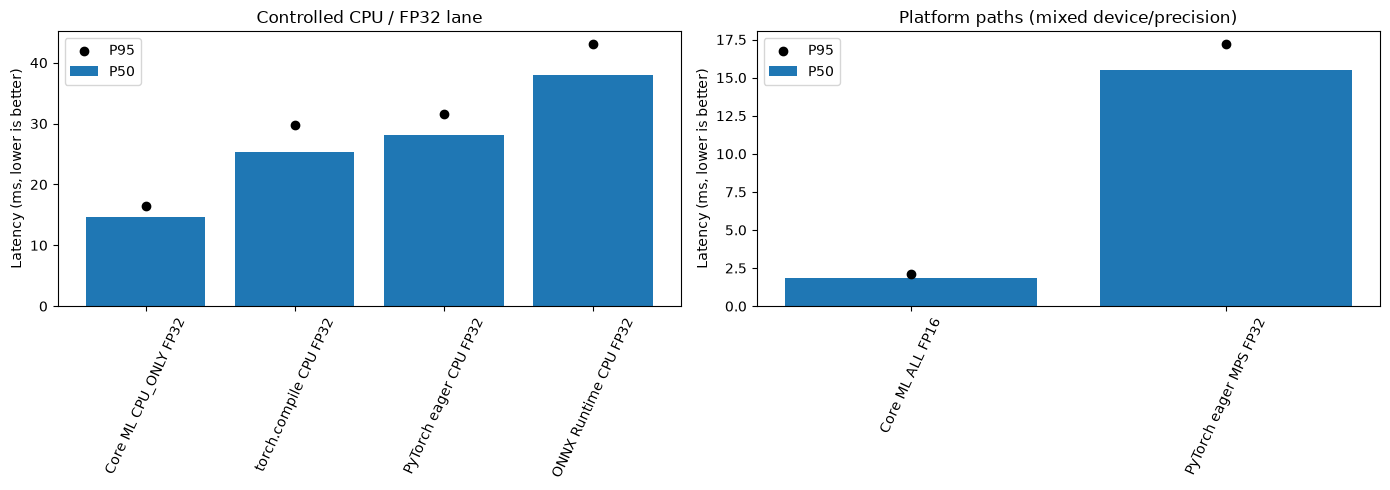

In [ ]:
controlled_plot = benchmark_summary.loc[
    benchmark_summary["lane"] == "controlled_cpu"
].sort_values("p50_ms")
platform_plot = benchmark_summary.loc[
    benchmark_summary["lane"] == "platform_path"
].sort_values("p50_ms")
figure, axes = plt.subplots(1, 2, figsize=(14, 5))

for axis, data, title in [
    (axes[0], controlled_plot, "Controlled CPU / FP32 lane"),
    (axes[1], platform_plot, "Platform paths (mixed device/precision)"),
]:
    axis.bar(data["backend"], data["p50_ms"], label="P50")
    axis.scatter(data["backend"], data["p95_ms"], color="black", label="P95", zorder=3)
    axis.set_title(title)
    axis.set_ylabel("Latency (ms, lower is better)")
    axis.tick_params(axis="x", rotation=65)
    axis.legend()

figure.tight_layout()
plt.show()

两图分别是受控 CPU lane 与平台路径的 warm steady latency，刻意不画成同一张“总排名”。上面的 phase table 用于理解每条流水线在哪些阶段花时间；由于各行起点不同（weights、已加载 module、ONNX、`.mlmodelc`），**不能跨行相加成 cold-start 总排名**。`torch.compile` 即使稳态更快，也要用很多次推理才能摊销；如果稳态反而更慢，就没有 break-even point。

## Checks 3：用 profiler 证明“底层调用不同”

benchmark 与 profiler 必须分离，因为 profiler 本身会增加开销。这里每条路径只做最小 inspection：

- PyTorch：ATen op 的 CPU time / shape。
- ORT：profile JSON 中 optimized node、provider、kernel time。
- Core ML：前面已保存 MIL + Compute Plan；实际硬件 timeline 用 Instruments。

In [ ]:
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU],
    record_shapes=True,
    profile_memory=True,
) as pytorch_profile:
    with torch.inference_mode():
        eager_model(input_tensor)

print(pytorch_profile.key_averages().table(sort_by="self_cpu_time_total", row_limit=15))
pytorch_profile.export_chrome_trace(str(PROFILE_DIR / "pytorch_eager_cpu_trace.json"))

---------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                             Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
---------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
       aten::_slow_conv2d_forward        68.52%      47.001ms        69.08%      47.385ms     894.063us      42.40 Mb     -45.03 Mb            53  
          aten::native_batch_norm         9.01%       6.179ms        10.78%       7.397ms     139.568us      42.40 Mb    -187.50 Kb            53  
                 aten::clamp_min_         7.38%       5.062ms         7.38%       5.062ms     103.308us           0 b           0 b            49  
                      aten::addmm         3.18%       2.182ms         3.20%       2.196ms       2.196ms       3.

In [ ]:
ort_profile_options = ort.SessionOptions()
ort_profile_options.enable_profiling = True
ort_profile_options.profile_file_prefix = str(PROFILE_DIR / "onnxruntime_cpu")
ort_profile_options.intra_op_num_threads = CPU_THREADS
ort_profile_options.inter_op_num_threads = 1
ort_profile_session = ort.InferenceSession(
    str(ONNX_PATH),
    sess_options=ort_profile_options,
    providers=["CPUExecutionProvider"],
)
ort_profile_session.run(["logits"], {"input": input_numpy})
ort_profile_path = Path(ort_profile_session.end_profiling())

ort_events = json.loads(ort_profile_path.read_text(encoding="utf-8"))
ort_node_events = [event for event in ort_events if event.get("cat") == "Node"]
ort_profile_df = pd.DataFrame(
    [
        {
            "node": event["name"],
            "op": event["args"].get("op_name"),
            "provider": event["args"].get("provider"),
            "duration_us": event["dur"],
        }
        for event in ort_node_events
    ]
).sort_values("duration_us", ascending=False)
display(ort_profile_df.head(15))
print(f"ORT profile: {ort_profile_path.relative_to(ROOT)}")

,node,op,provider,duration_us
28,node_Conv_1086_kernel_time,FusedConv,CPUExecutionProvider,3791
13,node_Conv_1058_kernel_time,FusedConv,CPUExecutionProvider,3183
0,node_Conv_1034_kernel_time,FusedConv,CPUExecutionProvider,2846
42,node_Conv_1116_kernel_time,FusedConv,CPUExecutionProvider,2835
26,node_Conv_1084_kernel_time,FusedConv,CPUExecutionProvider,2575
3,node_Conv_1038_kernel_time,FusedConv,CPUExecutionProvider,2528
27,node_Conv_1088_kernel_time,Conv,CPUExecutionProvider,2024
17,node_Conv_1066_kernel_time,FusedConv,CPUExecutionProvider,1874
45,node_Conv_1122_kernel_time,FusedConv,CPUExecutionProvider,1821
36,node_Conv_1104_kernel_time,FusedConv,CPUExecutionProvider,1734


ORT profile: results/phase0_resnet50/20260828-215306/profiler/onnxruntime_cpu_2026-08-28_22-11-41_179.json


`torch.profiler` 能看到 `aten::convolution` 等 dispatcher/runtime 视角；ORT profile 的 `FusedConv` 则证明 graph optimizer 已把若干 node 交给 CPU EP kernel。这两套名字不能按字符串一一对应，需要靠 shape、拓扑和输出边界做映射。

Core ML 的最终实测证据建议在 Xcode 中完成：

1. 双击 `artifacts/resnet50/resnet50_fp16.mlpackage`，查看 Xcode Performance report。
2. 用 Instruments 的 Core ML / Core AI 模板记录真实 CPU/GPU/ANE timeline。

`MLComputePlan` 是 anticipated placement；Instruments 才是实际运行证据。参考 [Apple MLModel utilities](https://apple.github.io/coremltools/docs-guides/source/mlmodel-utilities.html) 与 [Analyzing model runtime performance with Instruments](https://developer.apple.com/documentation/CoreAI/analyzing-model-runtime-performance-with-instruments)。

## Checks 4：保存可复现实验记录

不是只保存“最快一次”。本次运行写出环境、model hash、graph stats、全部 raw latency、summary、correctness 和 phase timing。

In [ ]:
graph_stats = {
    "torch_export_fx_nodes": len(fx_nodes),
    "torchscript_inlined_nodes": len(torchscript_nodes),
    "torch_dynamo_graph_count": dynamo_explain.graph_count,
    "torch_dynamo_graph_break_count": dynamo_explain.graph_break_count,
    "onnx_raw_nodes": len(onnx_model.graph.node),
    "onnx_optimized_nodes": len(optimized_onnx.graph.node),
    "onnx_raw_op_counts": dict(onnx_op_counts),
    "onnx_optimized_op_counts": dict(optimized_op_counts),
    "mil_after_default_passes_ops": len(mil_operations),
    "mil_op_counts": dict(mil_op_counts),
    "coreml_compute_plan_operations_with_usage": len(compute_plan_df),
}
artifact_manifest = {
    "torch_export": {"path": str(TORCH_EXPORT_PATH.relative_to(ROOT)), "sha256": sha256_path(TORCH_EXPORT_PATH), "size_mb": size_mb(TORCH_EXPORT_PATH)},
    "torchscript_trace": {"path": str(TORCHSCRIPT_PATH.relative_to(ROOT)), "sha256": sha256_path(TORCHSCRIPT_PATH), "size_mb": size_mb(TORCHSCRIPT_PATH)},
    "onnx": {"path": str(ONNX_PATH.relative_to(ROOT)), "sha256": sha256_path(ONNX_PATH), "size_mb": size_mb(ONNX_PATH)},
    "coreml_fp32_package": {"path": str(COREML_FP32_PACKAGE.relative_to(ROOT)), "sha256": sha256_path(COREML_FP32_PACKAGE), "size_mb": size_mb(COREML_FP32_PACKAGE)},
    "coreml_fp16_package": {"path": str(COREML_FP16_PACKAGE.relative_to(ROOT)), "sha256": sha256_path(COREML_FP16_PACKAGE), "size_mb": size_mb(COREML_FP16_PACKAGE)},
    "coreml_fp32_compiled": {"path": str(COREML_FP32_COMPILED.relative_to(ROOT)), "sha256": sha256_path(COREML_FP32_COMPILED), "size_mb": size_mb(COREML_FP32_COMPILED)},
    "coreml_fp16_compiled": {"path": str(COREML_FP16_COMPILED.relative_to(ROOT)), "sha256": sha256_path(COREML_FP16_COMPILED), "size_mb": size_mb(COREML_FP16_COMPILED)},
    "coreml_fp16_new_compiled": {"path": str(COREML_FP16_NEW_COMPILED.relative_to(ROOT)), "sha256": sha256_path(COREML_FP16_NEW_COMPILED), "size_mb": size_mb(COREML_FP16_NEW_COMPILED)},
}
manifest = {
    "environment": environment,
    "model_contract": model_contract,
    "protocol": {"warmup": WARMUP, "runs": RUNS, "cpu_threads": CPU_THREADS, "latency_scope": "prepared tensor to host-visible logits"},
    "artifacts": artifact_manifest,
    "graph_stats": graph_stats,
}

(RUN_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")
(RUN_DIR / "correctness.json").write_text(correctness_df.to_json(orient="records", indent=2, force_ascii=False), encoding="utf-8")
(RUN_DIR / "graph_stats.json").write_text(json.dumps(graph_stats, indent=2, ensure_ascii=False), encoding="utf-8")
latency_df.to_csv(RUN_DIR / "runtime.csv", index=False)
benchmark_summary.to_csv(RUN_DIR / "benchmark_summary.csv", index=False)
phase_timing.to_csv(RUN_DIR / "phase_timing.csv", index=False)

display(Markdown(f"本次实验结果目录：`{RUN_DIR.relative_to(ROOT)}`"))
display(pd.DataFrame(artifact_manifest).T)

本次实验结果目录：`results/phase0_resnet50/20260828-215306`

,path,sha256,size_mb
torch_export,artifacts/resnet50/resnet50_exported.pt2,d4143a4ce55200810d790059f016e3a1fd462f6dbb239c347b14aab695921035,103.593529
torchscript_trace,artifacts/resnet50/resnet50_traced.pt,9e6c50b8c3db0012148d9d083528554e28782e7374cf3cc8eb058d93d958ab39,102.833641
onnx,artifacts/resnet50/resnet50_imagenet1k_v2.onnx,155442e3cdea2a32f0cf5127f72ccdada44833a15104939e558d0765ac620fd4,102.370288
coreml_fp32_package,artifacts/resnet50/resnet50_fp32.mlpackage,3c9ee65904494ea40e77b6d9e792dcc8bdd0ae696887cc5c06ee506b53e70b5a,102.202629
coreml_fp16_package,artifacts/resnet50/resnet50_fp16.mlpackage,6619cca5bfe77f3573c675b4964dce351b6217f86a02b85e6cedf665d38a9d97,51.148642
coreml_fp32_compiled,artifacts/resnet50/resnet50_fp32.mlmodelc,0eaf690a2940cae0baa4169af55f8897e81c5d39a3299202215e06f6f72f4a86,102.219056
coreml_fp16_compiled,artifacts/resnet50/resnet50_fp16.mlmodelc,36b2845c13863d003d9cb47946db29938f923934ac3d6275c2b8910f0a5edb74,51.165046


## Takeaways：根据本机输出生成结论

下面只陈述这一次 run 能支持的结论；不把 M1 单机单图结果外推成所有模型/设备的规律。

In [ ]:
summary_by_backend = benchmark_summary.set_index("backend")
eager_p50 = summary_by_backend.loc["PyTorch eager CPU FP32", "p50_ms"]
compiled_p50 = summary_by_backend.loc["torch.compile CPU FP32", "p50_ms"]
saved_per_inference_ms = eager_p50 - compiled_p50
extra_first_ms = compiled_first_ms - eager_first_ms
if saved_per_inference_ms > 0:
    extra_steady_calls = np.ceil(extra_first_ms / saved_per_inference_ms)
    break_even = f"总计约 {extra_steady_calls + 1:.0f} 次（首帧后再跑约 {extra_steady_calls:.0f} 次）"
else:
    break_even = "不存在（compiled steady 没有比 eager 更快）"
coreml_p50 = summary_by_backend.loc["Core ML ALL FP16", "p50_ms"]
mps_p50 = summary_by_backend.loc["PyTorch eager MPS FP32", "p50_ms"]
total_plan_cost = compute_plan_df["estimated_weight"].sum()
neural_engine_cost = compute_plan_df.loc[
    compute_plan_df["preferred_device"].str.contains("NeuralEngine"), "estimated_weight"
].sum()
neural_engine_cost_share = 100 * neural_engine_cost / total_plan_cost

display(
    Markdown(
        f'''
- **Correctness：** 六条路径 Top-1 均为 `{categories[int(eager_output.argmax())]}`，且各自 tolerance gate 全部通过；Core ML FP16 的 max error 明显高于 FP32 lane，符合内部降精度预期。
- **CPU steady：** PyTorch eager P50 为 **{eager_p50:.2f} ms**，TorchInductor P50 为 **{compiled_p50:.2f} ms**；按这次 run 计算的 compile break-even 为 **{break_even}**。
- **平台路径：** PyTorch MPS FP32 P50 为 **{mps_p50:.2f} ms**，Core ML FP16/ALL P50 为 **{coreml_p50:.2f} ms**。这个差异同时包含 runtime、device placement 与 precision，不能只归因于 graph compiler。
- **Placement 证据：** Compute Plan 中 Neural Engine preferred operations 的 estimated cost share 为 **{neural_engine_cost_share:.1f}%**；这是编译器预期，仍需 Instruments 证明实际 timeline。
- **冷启动：** `torch.compile` 的第一次调用远大于 wrapper 创建；ONNX 把主要一次性成本放在 export/session；Core ML 明确产生 `.mlpackage → .mlmodelc` 两级 artifact。移动端服务的启动策略必须单独评估 cold path。
        '''
    )
)


- **Correctness：** 六条路径 Top-1 均为 `Samoyed`，且各自 tolerance gate 全部通过；Core ML FP16 的 max error 明显高于 FP32 lane，符合内部降精度预期。
- **CPU steady：** PyTorch eager P50 为 **28.14 ms**，TorchInductor P50 为 **25.39 ms**；按这次 run 计算的 compile break-even 为 **总计约 7337 次（首帧后再跑约 7336 次）**。
- **平台路径：** PyTorch MPS FP32 P50 为 **15.48 ms**，Core ML FP16/ALL P50 为 **1.87 ms**。这个差异同时包含 runtime、device placement 与 precision，不能只归因于 graph compiler。
- **Placement 证据：** Compute Plan 中 Neural Engine preferred operations 的 estimated cost share 为 **99.7%**；这是编译器预期，仍需 Instruments 证明实际 timeline。
- **冷启动：** `torch.compile` 的第一次调用远大于 wrapper 创建；ONNX 把主要一次性成本放在 export/session；Core ML 明确产生 `.mlpackage → .mlmodelc` 两级 artifact。移动端服务的启动策略必须单独评估 cold path。
        

## Next Steps

先不要进入量化。建议按下面顺序巩固这一个实验：

1. 把 `RUNS` 改成 100，彻底重启 kernel 后独立运行 3 次，比较三个 `runtime.csv` 的 P50/P95/方差；记录是否插电和机器温度状态。
2. 用 Netron 点开 ONNX 的第一组 Conv/Relu；再打开 compiled `model.mil`，手工找出对应的 `conv → relu`，建立第一次跨 IR 映射。
3. 用 Xcode Performance report / Instruments 验证 FP16 model 的真实 ANE placement，区分 Compute Plan 与 runtime evidence。
4. 下一份 notebook 进入 C2：保存 MIL pass 前后统计，观察 BatchNorm folding、cast、fusion、dead code elimination。

迁移到公司 SoC 时，保持输入、weights、correctness gate 和统计协议不变，只把 `MIL op → ComputePlan device` 替换为 `ONNX node → AP/AOM/task/kernel`。这就是 Foundation 与正式 Project 1 的接口。